In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools

cnot = pd.read_csv('data/data_cnot_fidelity_3ncut.txt')
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

tg_list = [50, 120, 190, 260, 330]
msteps = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]

### Infidelity convergence vs truncation

max_step=1e-3

In [2]:
f_ideal_100_1e3 = np.array([
-0.5608349753564063, -1.3975658834782951, -2.0665457484027208, -2.3235814871678384 ,
-2.535586441845595 ,
])
f_ideal_200_1e3 = np.array([
-0.5737523722918979, -1.4005184860845281, -2.112585440077793, -2.384846244500785 ,
-2.5973475824446344 ,
])
f_ideal_300_1e3 = np.array([
-0.5324359705702385, -1.3502950956175817, -2.5325404418610877, -3.1216704182570187 ,
-3.4526069327265807 ,
])
f_ideal_500_1e3 = np.array([
-0.49865589914762887, -1.314653543012705, -2.5215878831378236, -3.12079239264896 ,
-3.451329268792737 ,
])
f_ideal_1000_1e3 = np.array([
-0.48115027339792227, -1.282133780694707, -2.048601144284009, -2.8133466065899952 ,
-3.4029655386915025 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e3 = np.column_stack((f_ideal_100_1e3, f_ideal_200_1e3, f_ideal_300_1e3,
                               f_ideal_500_1e3, f_ideal_1000_1e3 ))

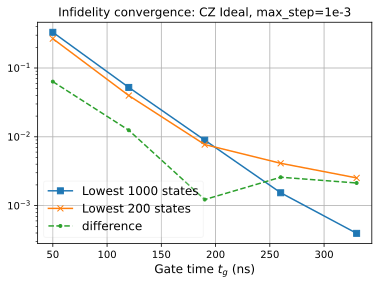

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000_1e3, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200_1e3, 'x-',  label=r'Lowest 200 states')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_1000_1e3 - 10**f_ideal_200_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

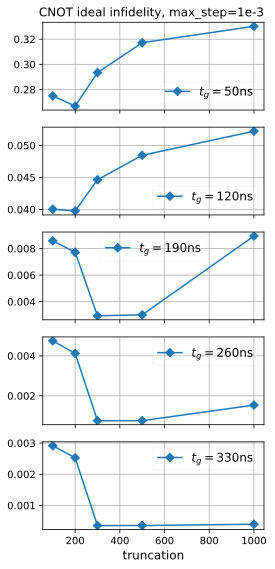

In [4]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e3[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

### Infidelity convergence vs truncation

max_step=1e-4

In [5]:
f_ideal_100_1e4 = np.array([
-0.5608268241656571, -1.3975974586179958, -2.0669584313983314, -2.3244064658170123 ,
-2.536911070070739 ,
])
f_ideal_200_1e4 = np.array([
-0.5737844200138282, -1.4005908979955024, -2.112915635596642, -2.385424076939623 ,
-2.59821471736574 ,
])
f_ideal_300_1e4 = np.array([
-0.53243029381785, -1.350229396988937, -2.532427917610461, -3.1215461634732913 ,
-3.452428649040791 ,
])
f_ideal_500_1e4 = np.array([
-0.4987371586900626, -1.316002596185962, -2.522619428124679, -3.1212413553554574 ,
-3.451383764325859 ,
])
f_ideal_1000_1e4 = np.array([
-0.48107804711348917, -1.2818215524954497, -2.070093844633445, -2.8256327125399876 ,
-3.4156157874624506 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_100_1e4, f_ideal_200_1e4, f_ideal_300_1e4,
                               f_ideal_500_1e4, f_ideal_1000_1e4 ))

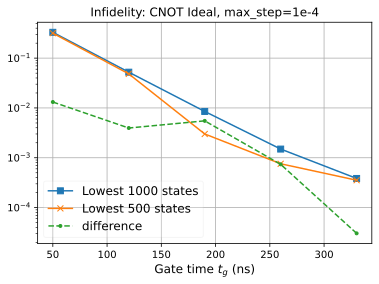

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000_1e4, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_500_1e4, 'x-',  label=r'Lowest 500 states')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_1000_1e4 - 10**f_ideal_500_1e4), '.--',  
        label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity: CNOT Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

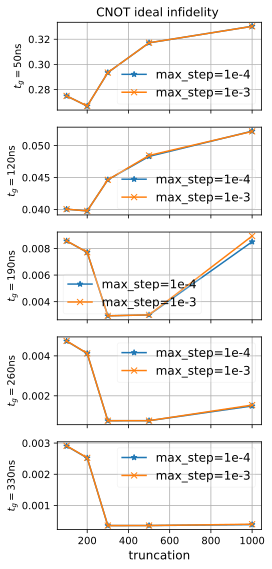

In [10]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], '*-', label=fr'max_step=1e-4')
    ax[i].plot(truc, 10**f_ideal_1e3[i], 'x-', label=fr'max_step=1e-3')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity ', fontsize=12)
plt.tight_layout()

### Infidelity convergence vs max_step

selected 110 states

In [ ]:
f_ideal_110_1e3 = np.array([
-0.5038292830031199, -1.3267637517474546, -2.5571541981405987, -3.1633836113782117 ,
-3.4805683672062053 ,
])
f_ideal_110_3e4 = np.array([
-0.5037842427356715, -1.3275235452899399, -2.560930477584596, -3.162944692125892 ,
-3.480454078048089 ,
])
f_ideal_110_1e4 = np.array([
-0.5037847247500232, -1.3275244861266038, -2.560914454378997, -3.1629302821063665 ,
-3.480482346346726 ,
])
f_ideal_110_3e5 = np.array([
-0.5037847181945132, -1.32750970283638, -2.560855063529726, -3.1628144010207557 ,
-3.480329379101597 ,
])
f_ideal_110_1e5 = np.array([
-0.5037838909702896, -1.32747855042218, -2.5608442416437165, -3.162872543112692 ,
-3.4804296613776535 ,
])

f_ideal_200 = np.column_stack((f_ideal_110_1e5, f_ideal_110_3e5, f_ideal_110_1e4, 
                               f_ideal_110_3e4, f_ideal_110_1e3 ))

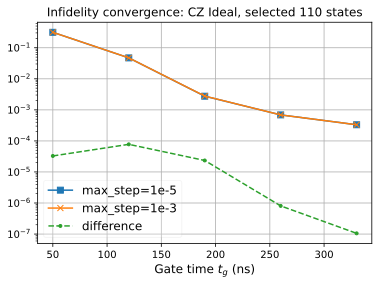

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_110_1e5, 's-',  label=r'max_step=1e-5')
ax.plot(tg_list, 10**f_ideal_110_1e3, 'x-',  label=r'max_step=1e-3')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_110_1e5 - 10**f_ideal_110_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, selected 110 states', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

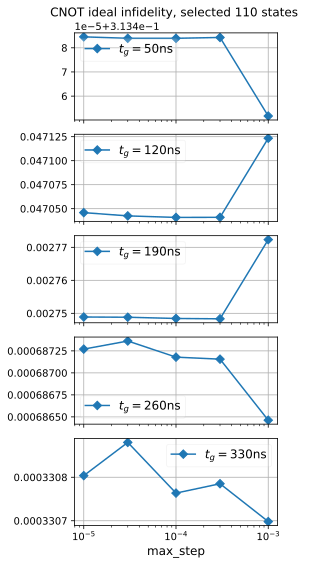

In [11]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(msteps, 10**f_ideal_200[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('max_step', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity, selected 110 states ', fontsize=12)
plt.tight_layout()

In [ ]:
=